In [1]:
import gc
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context
from pathlib import Path

import numpy as np
from numba import get_num_threads, set_num_threads

from core import (
    fit_gamma_from_poles,
    fit_power_law,
    format_a_for_filename,
    plot_a_gamma_fit,
    plot_decay_fit,
    plot_saved_pole_heatmap,
    plot_w0_starting_lines,
    pole_config_for_a as make_pole_config_for_a,
    pole_sensitivity_for_a as make_pole_sensitivity_for_a,
    run_selected_job,
    run_sweep_job,
    sweep_scan_filename,
)


In [2]:
# runtime
figure_dir = Path('figures')
figure_dir.mkdir(exist_ok=True)
worker_dir = Path('.worker_results')
worker_dir.mkdir(exist_ok=True)

num_threads = os.cpu_count() or 32

# numerical grid
eps = 1e-8

selected_a_values = [0.01, 0.1, 1.0, 10.0]
a_values = np.unique(np.concatenate([np.linspace(0.01, 10.0, 50), selected_a_values]))

def output_w_range(a_lst):
    w0_lst = np.zeros_like(a_lst)
    a_large = a_lst > 0.56
    w0_lst[a_large] = 1.11 + 0.39 * a_lst[a_large]
    w0_lst[~a_large] = 0.2 + 2.0 * a_lst[~a_large]
    return -w0_lst, w0_lst
    
w0_min_by_a, w0_max_by_a = output_w_range(a_values)
n_w0 = 5_000
w0_unit = np.linspace(0.0, 1.0, n_w0)
w0_real_arr_by_a = (
    w0_min_by_a[:, None]
    + (w0_max_by_a - w0_min_by_a)[:, None] * w0_unit[None, :]
)
w0_real_arr = w0_real_arr_by_a[0]  # representative grid for the starting-line plot
w0_imag_values = np.linspace(10.0, 10.1, 50)

# model
selected_plot_limits = {
    0.01: {'xlim': (-0.2, 0.2), 'ylim': (-0.8, 0.8)},
    0.1: {'xlim': (-0.4, 0.4), 'ylim': (-1.5, 1.0)},
    1.0: {'xlim': (-1.5, 1.5), 'ylim': (-3.0, 1.0)},
    10.0: {'xlim': (-5.0, 5.0), 'ylim': (-7.0, 0.5)},
}
m = 0.05
iter_range = 20
n_step = int(iter_range / m) + 1

# stability controls
denom_floor = 1e-16
g_abs_max = 1e16

# pole detection and sweep
low_sensitivity_max_a = 0.5
high_sensitivity_min_a = 3.0
low_a_pole_sensitivity = 0.6
mid_a_pole_sensitivity = 0.05
high_a_pole_sensitivity = 0.001
scan_stride = 1  # 1 is full-grid scanning; >1 is faster but less accurate.

# External workers 
worker_start_method = 'forkserver'
selected_n_jobs = max(1, min(len(selected_a_values), 4))
selected_thread_multiplier = 2
selected_num_threads_per_job = max(1, int(np.ceil(num_threads * selected_thread_multiplier / selected_n_jobs)))
sweep_n_jobs = max(1, min(len(a_values), 8))
sweep_thread_multiplier = 2
sweep_num_threads_per_job = max(1, int(np.ceil(num_threads * sweep_thread_multiplier / sweep_n_jobs)))

plot_start_stride = 1
plot_step_stride = 1
plot_x_padding = 0.2
plot_y_padding = 0.3
plot_log_vmin = -1.3
plot_log_vmax = 0.3
save_sweep_scan_outputs = True
save_sweep_scan_a_values = selected_a_values  # Use None to save every scanned a.
save_sweep_scan_compressed = False

set_num_threads(num_threads)
print(f"numba threads in notebook process: {get_num_threads()}")
print(f"n_step: {n_step}")
print(f"selected workers: {selected_n_jobs} x {selected_num_threads_per_job} threads")
print(f"sweep workers: {sweep_n_jobs} x {sweep_num_threads_per_job} threads")


numba threads in notebook process: 32
n_step: 401
selected workers: 4 x 16 threads
sweep workers: 8 x 8 threads


In [3]:
def pole_sensitivity_for_a(a_value):
    return make_pole_sensitivity_for_a(
        a_value,
        low_sensitivity_max_a,
        high_sensitivity_min_a,
        low_a_pole_sensitivity,
        mid_a_pole_sensitivity,
        high_a_pole_sensitivity,
    )


def pole_config_for_a(a_value):
    return make_pole_config_for_a(
        a_value,
        low_sensitivity_max_a,
        high_sensitivity_min_a,
        low_a_pole_sensitivity,
        mid_a_pole_sensitivity,
        high_a_pole_sensitivity,
    )


print('pole detection sensitivity by a:')
print(f'  a <= {low_sensitivity_max_a:g}: {low_a_pole_sensitivity}')
print(f'  {low_sensitivity_max_a:g} < a < {high_sensitivity_min_a:g}: {mid_a_pole_sensitivity}')
print(f'  a >= {high_sensitivity_min_a:g}: {high_a_pole_sensitivity}')


pole detection sensitivity by a:
  a <= 0.5: 0.6
  0.5 < a < 3: 0.05
  a >= 3: 0.001


In [4]:
def write_worker_inputs():
    worker_dir.mkdir(exist_ok=True)
    np.save(worker_dir / 'a_values.npy', a_values)
    np.save(worker_dir / 'w0_real_arr_by_a.npy', w0_real_arr_by_a)
    np.save(worker_dir / 'w0_imag_values.npy', w0_imag_values)
    return {
        'eps': eps,
        'm': m,
        'n_step': n_step,
        'denom_floor': denom_floor,
        'g_abs_max': g_abs_max,
        'low_sensitivity_max_a': low_sensitivity_max_a,
        'high_sensitivity_min_a': high_sensitivity_min_a,
        'low_a_pole_sensitivity': low_a_pole_sensitivity,
        'mid_a_pole_sensitivity': mid_a_pole_sensitivity,
        'high_a_pole_sensitivity': high_a_pole_sensitivity,
        'scan_stride': scan_stride,
        'plot_start_stride': plot_start_stride,
        'plot_step_stride': plot_step_stride,
        'plot_x_padding': plot_x_padding,
        'plot_y_padding': plot_y_padding,
        'plot_log_vmin': plot_log_vmin,
        'plot_log_vmax': plot_log_vmax,
        'save_sweep_scan_outputs': save_sweep_scan_outputs,
        'save_sweep_scan_a_values': save_sweep_scan_a_values,
        'save_sweep_scan_compressed': save_sweep_scan_compressed,
        'selected_plot_limits': {
            str(a_value): limits
            for a_value, limits in selected_plot_limits.items()
        },
    }


def make_worker_context():
    try:
        return get_context(worker_start_method)
    except ValueError:
        return get_context('spawn')


def run_worker_batch(jobs, max_workers, worker_func):
    config = write_worker_inputs()
    os.environ['MPLBACKEND'] = 'Agg'
    os.environ['OPENBLAS_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'

    prepared_jobs = []
    for job in jobs:
        prepared_job = dict(job)
        prepared_job['config'] = config
        prepared_job['grid_dir'] = str(worker_dir)
        prepared_job['figure_dir'] = str(figure_dir)
        prepared_job['scan_output_dir'] = str(worker_dir)
        prepared_jobs.append(prepared_job)

    results = []
    context = make_worker_context()
    with ProcessPoolExecutor(max_workers=max_workers, mp_context=context) as executor:
        futures = {
            executor.submit(worker_func, job): job
            for job in prepared_jobs
        }
        for future in as_completed(futures):
            result = future.result()
            results.append(result)
            if 'gamma' in result:
                print(
                    f"a = {result['a']:g}: sweep found {result['n_poles']} pole candidates, "
                    f"gamma = {result['gamma']:.6f}, threads = {result['threads']}"
                )
            else:
                print(
                    f"a = {result['a']:g}: found {result['n_poles']} pole candidates, "
                    f"threads = {result['threads']}"
                )
    return results


def compute_selected_results_parallel():
    jobs = [
        {
            'index': int(np.flatnonzero(np.isclose(a_values, a_i))[0]),
            'a': float(a_i),
            'threads': selected_num_threads_per_job,
        }
        for a_i in selected_a_values
    ]
    results = run_worker_batch(jobs, selected_n_jobs, run_selected_job)
    selected_order = {a_i: idx for idx, a_i in enumerate(selected_a_values)}
    results.sort(key=lambda result: selected_order[result['a']])
    return results


def sweep_gamma_vs_a(a_values):
    jobs = [
        {
            'index': idx,
            'a': float(a_i),
            'threads': sweep_num_threads_per_job,
        }
        for idx, a_i in enumerate(a_values)
    ]
    results = run_worker_batch(jobs, sweep_n_jobs, run_sweep_job)

    gamma_values = np.empty(len(a_values), dtype=np.float64)
    gamma_errors = np.empty(len(a_values), dtype=np.float64)
    for result in results:
        idx = result['idx']
        gamma_values[idx] = result['gamma']
        gamma_errors[idx] = result['gamma_err']
    return gamma_values, gamma_errors


def sweep_scan_path(a_value):
    return worker_dir / sweep_scan_filename(a_value)


def load_sweep_scan(a_value, mmap_mode='r'):
    return np.load(sweep_scan_path(a_value), mmap_mode=mmap_mode)


def plot_sweep_scan_from_npz(
    a_value,
    xlim=None,
    ylim=None,
    log_vmin=None,
    log_vmax=None,
    save_path=None,
    show=True,
):
    data = load_sweep_scan(a_value)
    heatmap_x = data['heatmap_x']
    heatmap_y = data['heatmap_y']
    heatmap_z = data['heatmap_z']
    pole_w = data['pole_w']

    if xlim is None or ylim is None:
        if 'plot_xlim' in data.files and 'plot_ylim' in data.files:
            xlim = tuple(data['plot_xlim']) if xlim is None else xlim
            ylim = tuple(data['plot_ylim']) if ylim is None else ylim
        else:
            limits = selected_plot_limits.get(a_value)
            if limits is not None:
                xlim = limits['xlim'] if xlim is None else xlim
                ylim = limits['ylim'] if ylim is None else ylim

    if xlim is None:
        xlim = (float(np.nanmin(heatmap_x)), float(np.nanmax(heatmap_x)))
    if ylim is None:
        ylim = (float(np.nanmin(heatmap_y)), float(np.nanmax(heatmap_y)))

    if log_vmin is None:
        saved_log_vmin = float(data['plot_log_vmin']) if 'plot_log_vmin' in data.files else np.nan
        log_vmin = saved_log_vmin if np.isfinite(saved_log_vmin) else plot_log_vmin
    if log_vmax is None:
        saved_log_vmax = float(data['plot_log_vmax']) if 'plot_log_vmax' in data.files else np.nan
        log_vmax = saved_log_vmax if np.isfinite(saved_log_vmax) else plot_log_vmax

    plot_saved_pole_heatmap(
        heatmap_x,
        heatmap_y,
        heatmap_z,
        pole_w,
        xlim=xlim,
        ylim=ylim,
        title=f'a = {a_value:g}: Pole Candidates from Saved Sweep Scan',
        save_path=save_path,
        show=show,
        log_vmin=log_vmin,
        log_vmax=log_vmax,
    )


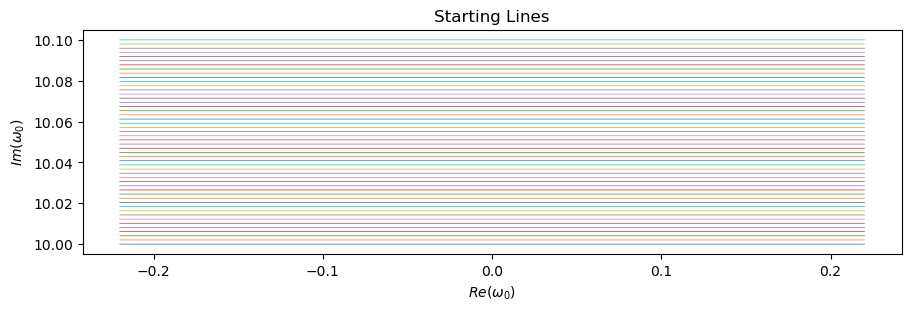

computing 4 selected a values with 4 processes x 16 numba threads
a = 0.01: found 5 pole candidates, threads = 16
a = 0.1: found 16 pole candidates, threads = 16
a = 10: found 139 pole candidates, threads = 16
a = 1: found 33 pole candidates, threads = 16


7655

In [5]:
# 2D plots and selected poles for representative a values
plot_w0_starting_lines(
    w0_real_arr,
    w0_imag_values,
    save_path=figure_dir / 'w0_starting_lines.pdf',
)

print(
    f'computing {len(selected_a_values)} selected a values with '
    f'{selected_n_jobs} processes x {selected_num_threads_per_job} numba threads'
)
computed_results = compute_selected_results_parallel()
selected_results = {
    result['a']: {
        'pole_w': result['pole_w'],
        'pole_strength': result['pole_strength'],
    }
    for result in computed_results
}
gc.collect()


gamma = 1.230981 +/- 0.037517


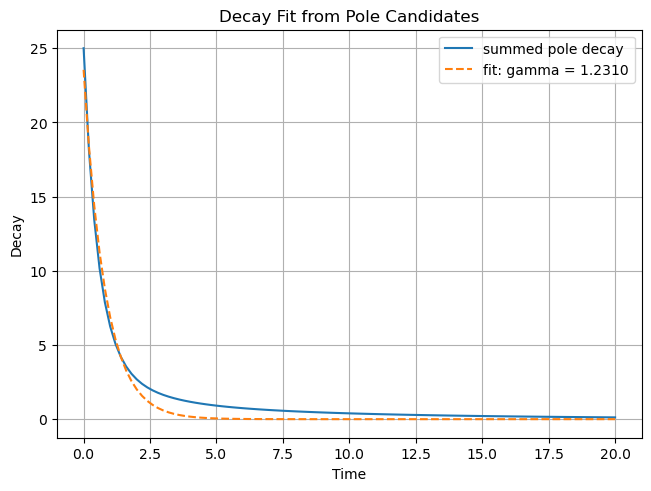

In [6]:
# decay fit for a = 1
decay_a = 1.0
gamma, gamma_err, time, decay_curves, fit_curve = fit_gamma_from_poles(
    selected_results[decay_a]['pole_w']
)
print(f'gamma = {gamma:.6f} +/- {gamma_err:.6f}')
plot_decay_fit(
    gamma,
    time,
    decay_curves,
    fit_curve,
    save_path=figure_dir / f'decay_fit_a_{format_a_for_filename(decay_a)}.pdf',
)


sweeping 52 a values with 8 processes x 8 numba threads (scan_stride = 1)
a = 0.417755: sweep found 34 pole candidates, gamma = 0.780384, threads = 8
a = 0.213878: sweep found 23 pole candidates, gamma = 0.446055, threads = 8
a = 0.1: sweep found 16 pole candidates, gamma = 0.321642, threads = 8
a = 0.01: sweep found 5 pole candidates, gamma = 0.175172, threads = 8
a = 1.02939: sweep found 33 pole candidates, gamma = 1.197539, threads = 8
a = 1: sweep found 33 pole candidates, gamma = 1.230981, threads = 8
a = 0.82551: sweep found 30 pole candidates, gamma = 0.998511, threads = 8
a = 0.621633: sweep found 27 pole candidates, gamma = 0.966968, threads = 8
a = 1.8449: sweep found 47 pole candidates, gamma = 1.384336, threads = 8
a = 1.64102: sweep found 45 pole candidates, gamma = 1.452619, threads = 8
a = 1.43714: sweep found 39 pole candidates, gamma = 1.253846, threads = 8
a = 1.23327: sweep found 37 pole candidates, gamma = 1.316555, threads = 8
a = 2.25265: sweep found 52 pole candi

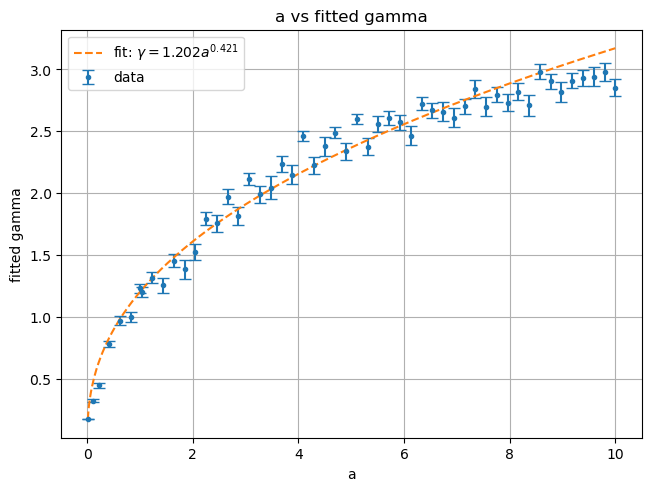

In [7]:
# sweep a and fit gamma = C * a^x
print(
    f'sweeping {len(a_values)} a values with '
    f'{sweep_n_jobs} processes x {sweep_num_threads_per_job} numba threads '
    f'(scan_stride = {scan_stride})'
)
gamma_values, gamma_errors = sweep_gamma_vs_a(a_values)
C, C_err, x, x_err, fit_a, fit_gamma = fit_power_law(a_values, gamma_values, gamma_errors)

if np.isfinite(C) and np.isfinite(x):
    print(f'log-space power-law fit: gamma = {C:.6f} * a^{x:.6f}')
    print(f'C = {C:.6f} +/- {C_err:.6f}')
    print(f'x = {x:.6f}     +/- {x_err:.6f}')
else:
    print('not enough valid gamma values for power-law fit')

plot_a_gamma_fit(
    a_values,
    gamma_values,
    gamma_errors,
    C,
    x,
    fit_a,
    save_path=figure_dir / 'gamma_vs_a_power_law_fit.pdf',
)


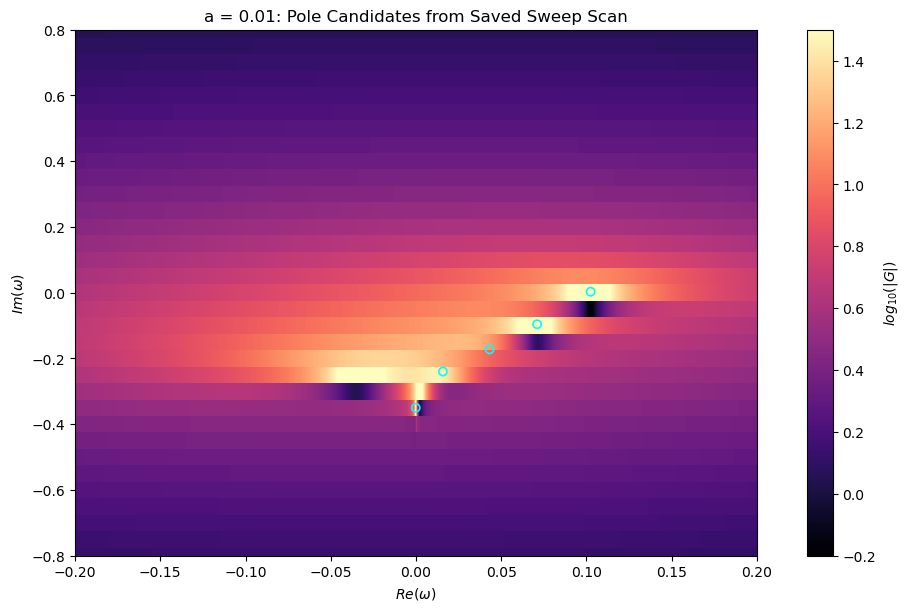

saved figures/sweep_pole_heatmap_a_0p01.pdf


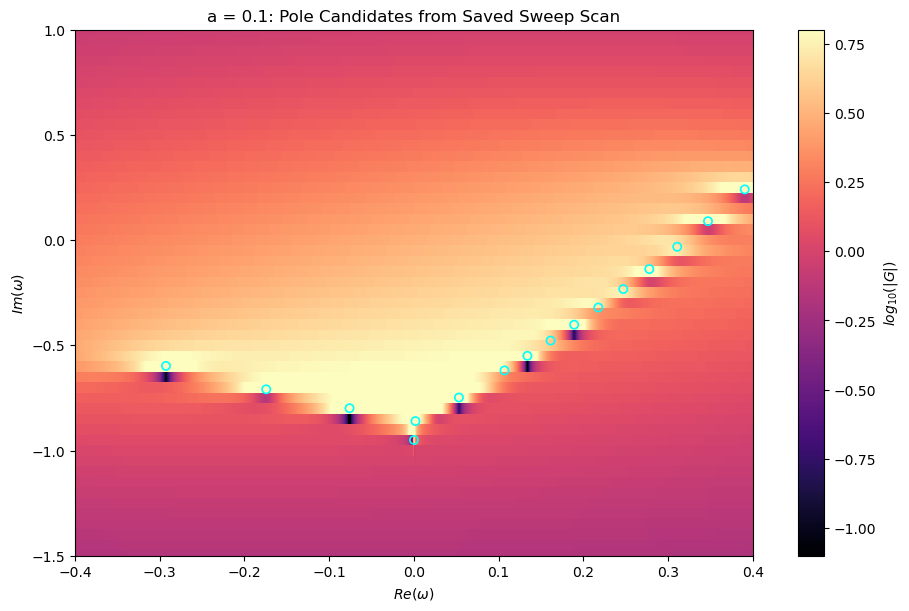

saved figures/sweep_pole_heatmap_a_0p1.pdf


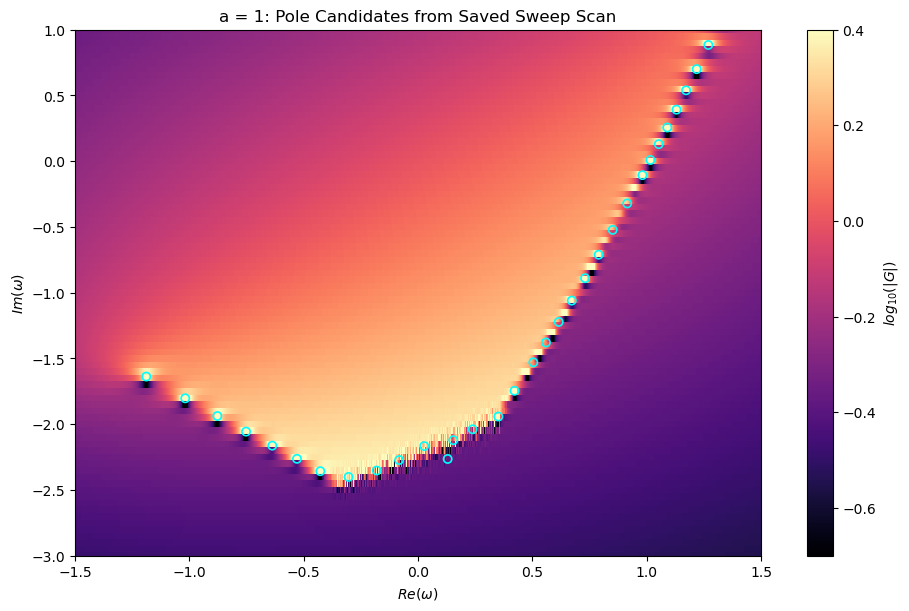

saved figures/sweep_pole_heatmap_a_1.pdf


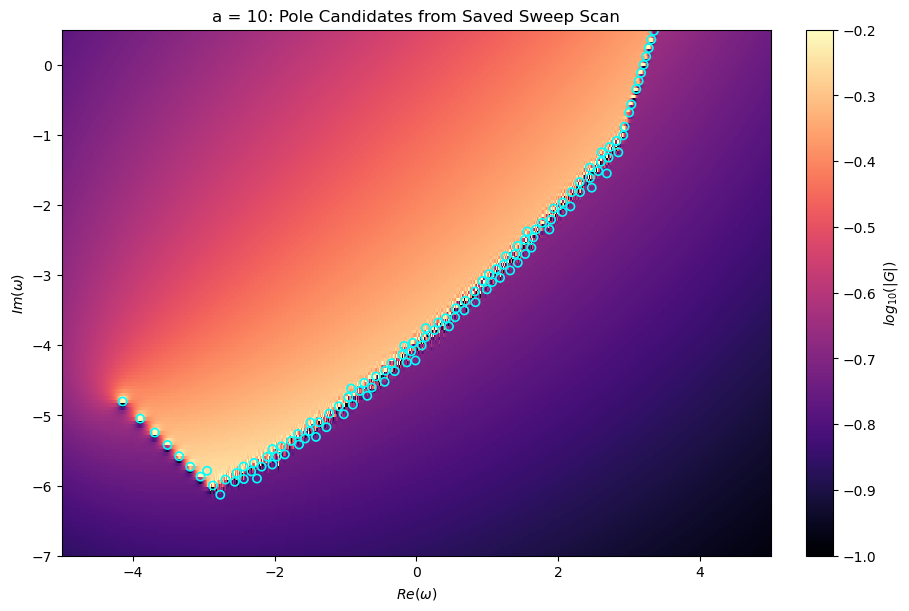

saved figures/sweep_pole_heatmap_a_10.pdf


In [8]:
# save representative pole heatmaps from saved sweep scan files

save_path = figure_dir / f'sweep_pole_heatmap_a_{format_a_for_filename(0.01)}.pdf'
plot_sweep_scan_from_npz(
    0.01,
    log_vmin=-0.2,
    log_vmax=1.5,
    save_path=save_path,
    show=True,
)
print(f'saved {save_path}')
save_path = figure_dir / f'sweep_pole_heatmap_a_{format_a_for_filename(0.1)}.pdf'
plot_sweep_scan_from_npz(
    0.1,
    log_vmin=-1.1,
    log_vmax=0.8,
    save_path=save_path,
    show=True,
)
print(f'saved {save_path}')
save_path = figure_dir / f'sweep_pole_heatmap_a_{format_a_for_filename(1)}.pdf'
plot_sweep_scan_from_npz(
    1,
    log_vmin=-0.7,
    log_vmax=0.4,
    save_path=save_path,
    show=True,
)
print(f'saved {save_path}')
save_path = figure_dir / f'sweep_pole_heatmap_a_{format_a_for_filename(10)}.pdf'
plot_sweep_scan_from_npz(
    10,
    log_vmin=-1.0,
    log_vmax=-0.2,
    save_path=save_path,
    show=True,
)
print(f'saved {save_path}')
